# Wordle: Gemma + LoRA + ES

Train a **linear head** on a Hugging Face causal LM with **Evolution Strategies**. This Week 11 notebook keeps the full **`google/gemma-3-1b-it`** path available, but now defaults to a **smoke-test profile** so you can verify the workflow quickly before committing to a long run. Switch `RUN_PROFILE` in §2 to move from fast validation to the fuller Gemma setup.

**Also:** Richer prompts with **structured constraints** from feedback; optional **supervised warm-start** (cross-entropy to the secret word; label only, not in the prompt).

**Requires:** `torch`, `transformers>=4.50.0`, `jinja2>=3.1.0` for chat-template models such as Gemma, `numpy`, `matplotlib`. **`pip install peft`** only if `USE_LORA=True` in §2. First run downloads HF weights.

## 1. Environment and imports

`peft` is **not** imported here (only needed for `USE_LORA=True`). Install it yourself if you enable LoRA.

**If you see `apply_chat_template requires jinja2>=3.1.0`:** run `python -m pip install -U 'jinja2>=3.1.0'` in the active notebook environment, then restart the kernel.

**If you see `unexpected keyword argument 'normalize_gradient'`:** restart the kernel and run this cell again, or rely on `importlib.reload` below (re-run this cell after editing `src/es_wordle.py`).

In [1]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import torch

# Fall back to standard HF downloads; Xet caused import/download issues in this env.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

# Repo root + src on path (works from `notebooks/` or project root)
_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import wordle_env
importlib.reload(wordle_env)
from wordle_env import load_wordle_environment

from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

# Always pick up the latest es_wordle.py (Jupyter caches imports)
import es_wordle
importlib.reload(es_wordle)

from es_wordle import train_es_wordle, train_curriculum

import inspect
_sig = inspect.signature(train_es_wordle)
for _name in (
    "normalize_gradient",
    "eval_deterministic",
    "antithetic",
    "common_random_numbers",
    "ema_beta",
    "baseline_subtract",
):
    if _name not in _sig.parameters:
        raise RuntimeError(
            f"src/es_wordle.py is missing {_name}. Re-run the import cell after `importlib.reload`, or pull the latest repo."
        )

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("Install transformers: pip install transformers")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps_backend = getattr(torch.backends, "mps", None)
    if mps_backend is not None and mps_backend.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> tuple[dict, str]:
    if device.type != "cuda":
        return {}, "float32"
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}, "bfloat16"
    return {"torch_dtype": torch.float16}, "float16"


def _parse_version_tuple(version: str) -> tuple[int, ...]:
    parts = []
    for chunk in version.split("."):
        digits = ""
        for ch in chunk:
            if ch.isdigit():
                digits += ch
            else:
                break
        if not digits:
            break
        parts.append(int(digits))
    return tuple(parts)


def require_chat_template_support() -> None:
    try:
        import jinja2
    except ImportError as exc:
        raise ImportError(
            "Chat-template models require `jinja2>=3.1.0`. Install or upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        ) from exc

    installed = getattr(jinja2, "__version__", "0")
    if _parse_version_tuple(installed) < (3, 1, 0):
        raise ImportError(
            f"Chat-template models require `jinja2>=3.1.0`, but found {installed}. Upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        )


print("ROOT:", ROOT)
print("es_wordle:", es_wordle.__file__)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("HF_HUB_DISABLE_XET:", os.environ["HF_HUB_DISABLE_XET"])
if torch.cuda.is_available():
    print("cuda_device:", torch.cuda.get_device_name(0))

ROOT: /home/ubuntu/STAT-4830-project-base
es_wordle: /home/ubuntu/STAT-4830-project-base/src/es_wordle.py
torch: 2.11.0+cu126 | cuda: True
HF_HUB_DISABLE_XET: 1
cuda_device: NVIDIA A100-SXM4-80GB


## 2. Hyperparameters

The next cell now supports two profiles:

- **`RUN_PROFILE="smoke"`**: fast validation path using a smaller model and short ES/warm-start settings.
- **`RUN_PROFILE="gemma_full"`**: restores the fuller Week 11 Gemma configuration for a real run.

Additional notes:

- **`MODEL_LOAD_KWARGS`**: automatically picks a GPU-friendly dtype on CUDA (`bfloat16` when supported, else `float16`). CPU stays on `float32`.
- **`USE_CHAT_TEMPLATE`**: stays enabled for Gemma instruction checkpoints and disabled for the smoke-test GPT-2 path.
- **`MOCK_ENV`**: remains `True` by default so validation runs stay bounded and always have the target word in the action set.
- **`N_POP` / `N_ITERATIONS` / `WARM_START_STEPS`**: are profile-controlled so the smoke path stays quick while the Gemma path keeps the heavier settings. `N_ITERATIONS` is now interpreted as iterations **per curriculum stage**.
- **`vocab_schedule`**: per-profile list of action-set sizes. `train_curriculum` runs ES at each size in turn, growing both the policy head and the env's secret pool together (see §5). The env is built with `target_pool=policy.words` so every episode is in-principle winnable. Use a single-element schedule (e.g. `[N]`) to disable curriculum.
- **`USE_LORA`**: still defaults to `False` so validation only trains the head unless you explicitly enable adapters.

## 2b. `ACTIVE_EXPERIMENT='exp2_overshoot'` — step-size / overshoot hypothesis

Session 7 found that mini-batch ES under CRN (Exp 2) gained **+18pp greedy at iter 1** then walked away from it (final **−12pp vs post-WS**). Diagnosis: 4-word subset rotates each iter, ALPHA calibrated at iter 0 assumes a stationary objective, per-iter step ≈ 3-4× the calibration target → random walk around the post-WS basin. This experiment tests the fix:

- **ALPHA × 0.25** (via `ALPHA_SCALE = 0.25` → applied post-calibration in cell 12).
- **N_ITERATIONS = 60** (double Session 7's budget, so total θ drift lands near the calibrated target).
- **`track_best_iter=True` + `restore_best_on_finish=True`** with **`EVAL_DETERMINISTIC=False`** (updated API in `train_curriculum` / `train_es_wordle`). This keeps stochastic periodic eval while restoring the best-seen iterate at stage end.

### Verdict (grade in order, against `best_greedy`)

- **PASS-A:** `best_greedy − post_ws_greedy ≥ +10pp` AND `final_greedy ≥ post_ws_greedy` AND `dprobe` non-zero ≥ 25% → step-size fix alone is sufficient; ES converges on its own.
- **PASS-B:** `best_greedy ≥ +10pp` lift but `final_greedy < best_greedy − 10pp` → best-iter restore is load-bearing; hypothesis confirmed (restore is the mitigation).
- **FAIL:** neither → proceed to sticky-subset FAIL branch (`EXP2_SUBSET_REFRESH_EVERY=5`).

Notebook parity with the headline runner at [`scripts/run_experiment2_minibatch_crn.py`](../scripts/run_experiment2_minibatch_crn.py); the full run uses the script, not the notebook.

In [2]:
# --- Hyperparameters (switch RUN_PROFILE for longer runs) ---

SEED = 42
RUN_PROFILE = "gemma_full"  # "smoke" or "gemma_full"
DEVICE = choose_device()

MOCK_ENV = False
USE_PRIME_TARGETS = True
USE_LORA = True  # Leave False for validation; enable only if you want PEFT adapters.
# Single rank only (was a [1, 2, 4] sweep). Prior random-walk drift at r in {64, 128}
# was a population-size problem, not a capacity problem; sweeping tiny ranks is 3x
# wall-clock for ~no information, and the saved compute funds the post-warm-start
# diagnostic + the late-stage iter reshape.
LORA_R = 8
RICHER_PROMPT = True
WARM_START_LR = 3e-4
SIGMA = 0.02
# ALPHA = None enables auto-calibration in cell 5: the calibration probe there
# already computes a `_suggested_alpha` that yields an initial step ≈ 0.13 at
# the current LORA_R / N_POP / sigma combination. Set to a float here only if
# you want to override the calibrator (e.g. to reproduce an old run). The
# rationale: the rank-fitness raw ‖ĝ‖ scales with sqrt(n_params/N_POP)/sigma,
# so the right ALPHA shifts whenever LORA_R or N_POP changes; pinning a
# constant here was the original cause of the "Step‖ too small" failure mode
# that produced cos(ĝ) ≈ 0 across iterations.
ALPHA = None
NORMALIZE_GRADIENT = False  # Let weak-signal steps be small and strong-signal steps large.
RANK_FITNESS = True
# Phase C: PGPE-lite raw baseline-subtracted fitness. Takes precedence over
# RANK_FITNESS when True. Recommended when ES diagnostics show the
# "most members tie at lost-everything" failure mode (small wins/N_POP per iter,
# cos(ĝ) ≈ 0 across iters, dprobe ≈ 0). The 20-iter probe at N_POP=64 / n_eval=16
# explicitly FAILed both pass criteria (median cos(ĝ) = -0.000, eval lift = +12pp
# vs. +15pp threshold) under rank-fitness; baseline subtraction preserves the
# magnitude of the win signal that win_fitness_scale=8 injects (which the rank
# transform's std-normalization renormalizes away when ties dominate).
BASELINE_SUBTRACT = True
# ES SNR upgrades: antithetic pairs + common random numbers reduce per-iteration
# gradient variance for free (same wall-clock); EMA momentum lets the persistent
# signal accumulate across iterations instead of diffusing.
ANTITHETIC = True            # Requires N_POP to be even (gemma_full N_POP=16 is fine).
COMMON_RANDOM_NUMBERS = True  # Same secret words + sampling for every member in an iter.
# EMA momentum was actively *hurting* with BASELINE_SUBTRACT=True. Diagnosis from
# the second probe run: per-iter raw gradient norm was roughly stable (~4000) but
# Grad‖ (post-EMA) decayed monotonically 3953 -> 802 over 13 iters while Step‖
# fell from 0.13 to 0.026, because successive raw gradients were uncorrelated
# (cos(ĝ) ≈ 0) and EMA averaged them toward zero. With EMA off, every iter
# applies the full-magnitude raw gradient in its own direction; even with
# cos(ĝ) ≈ 0, the *expected* gradient over many iters still points the right
# way, so the parameter trajectory accumulates real progress (standard SGD-on-
# stochastic-gradient regime). Re-enable EMA only if cos(ĝ) is reliably > ~0.1.
EMA_BETA = 0.0               # 0.0 disables momentum; 0.9 is a safe Adam-like default.
EVAL_DETERMINISTIC = True  # greedy eval: Success % reflects argmax policy (clearer after warm-start)
FITNESS_OBJECTIVE = "win_plus_return"
WIN_FITNESS_SCALE = 8.0

PROFILE_CONFIGS = {
    "smoke": {
        "model_name": "distilgpt2",
        "use_chat_template": False,
        "chat_generation_prompt": False,
        "max_prompt_length": 256,
        "vocab_schedule": [8],
        "n_eval_episodes": 1,
        "eval_n_episodes": 4,
        "eval_every": 1,
        "warm_start_steps": 12,
        "n_pop": 4,
        "n_iterations": 2,
        "num_train_examples": 128,
        "num_eval_examples": 16,
    },
    "gemma_full": {
        "model_name": "google/gemma-3-1b-it",
        "use_chat_template": True,
        "chat_generation_prompt": True,
        "max_prompt_length": 512,
        "vocab_schedule": [16, 32, 64, 96, 128, 256, 512, 1024],
        # SNR rebalance (post-Phase-A probe). The previous N_POP=16 with
        # antithetic gave only 8 effective directions; combined with
        # n_eval_episodes=4 under CRN, only 4 secrets were discriminating
        # all 16 members and the per-iter ES gradient was variance-dominated
        # (cos(ĝ) ≈ 0 across the entire run). 4x both knobs.
        "n_eval_episodes": 16,
        "eval_n_episodes": 50,
        "eval_every": 1,
        # Halved warm-start budget. Combined with the warm_start_max_post_ws_success
        # ceiling threaded into train_curriculum, this guarantees every stage
        # leaves ES at least ~15% headroom to act on. Without this, mid stages
        # post-WS hit 96-100% and ES had nothing to optimize.
        "warm_start_steps": 200,
        "n_pop": 64,
        # Per-stage iters (sums to ~180, comparable to old 160). Reallocates
        # away from the early stages (where warm-start saturates and ES has
        # no headroom) toward the late stages where the generalization problem
        # actually lives.
        "n_iterations": [3, 3, 5, 8, 15, 30, 45, 70],
        "num_train_examples": 2000,
        "num_eval_examples": 20,
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"RUN_PROFILE must be one of {sorted(PROFILE_CONFIGS)}, got {RUN_PROFILE!r}")

cfg = PROFILE_CONFIGS[RUN_PROFILE]
MODEL_NAME = cfg["model_name"]
USE_CHAT_TEMPLATE = cfg["use_chat_template"]
if USE_CHAT_TEMPLATE:
    require_chat_template_support()
CHAT_GENERATION_PROMPT = cfg["chat_generation_prompt"]
MAX_PROMPT_LENGTH = cfg["max_prompt_length"]
N_EVAL_EPISODES = cfg["n_eval_episodes"]
EVAL_N_EPISODES = cfg["eval_n_episodes"]
EVAL_EVERY = cfg["eval_every"]
WARM_START_STEPS = cfg["warm_start_steps"]
N_POP = cfg["n_pop"]
N_ITERATIONS = cfg["n_iterations"]
NUM_TRAIN_EXAMPLES = cfg["num_train_examples"]
NUM_EVAL_EXAMPLES = cfg["num_eval_examples"]

# Mock: action space == secret pool only → every episode solvable; ES / eval see real wins.
if MOCK_ENV:
    from wordle_env import MOCK_WORDLE_TARGETS as _MOCK_T
    _MOCK_ACTIONS = len(_MOCK_T)
else:
    _MOCK_ACTIONS = None

# Curriculum vocabulary schedule: list of action-set sizes, monotonically growing.
# Each stage trains ES at its size, with the env's secret pool restricted to
# `policy.words` so every episode is in-principle winnable. With MOCK_ENV=True
# the schedule collapses to the mock action set so behaviour matches earlier
# notebooks.
if MOCK_ENV:
    VOCAB_SCHEDULE = [_MOCK_ACTIONS]
else:
    VOCAB_SCHEDULE = list(cfg["vocab_schedule"])

if not VOCAB_SCHEDULE:
    raise ValueError("vocab_schedule must contain at least one stage size.")
if any(b < a for a, b in zip(VOCAB_SCHEDULE, VOCAB_SCHEDULE[1:])):
    raise ValueError(f"vocab_schedule must be non-decreasing, got {VOCAB_SCHEDULE!r}")

INITIAL_VOCAB = VOCAB_SCHEDULE[0]
MAX_VOCAB = VOCAB_SCHEDULE[-1]
MODEL_LOAD_KWARGS, MODEL_DTYPE_NAME = default_model_load_kwargs(DEVICE)

# Per-stage train/held-out split on the secret pool. Two semantics, controlled
# by HOLDOUT_MODE:
#
#   - "episode" (default): same vocab in train and eval. The held-out signal
#     comes from eval rollouts naturally drawing different secrets / first-guess
#     prefixes from training rollouts (different RNG positions inside the env).
#     Eval measures generalization to *fresh game episodes* and is answerable
#     by the architecture (the head can in principle argmax to any eval secret).
#     SECRET_HOLDOUT_FRAC is ignored in this mode (kept here only for the
#     "word"-mode legacy path below).
#
#   - "word": legacy split. SECRET_HOLDOUT_FRAC of the per-stage pool is
#     reserved as a disjoint held-out *vocabulary* (the suffix), never seen as
#     warm-start CE target nor as an ES winner. Under greedy argmax over the
#     full action space this yields a structurally-forced 0% on held-out --
#     the head is never trained to emit those words. Use only for explicit
#     out-of-vocab generalization experiments.
#
# MASKED_EVAL_SANITY_PROBE turns on a per-stage diagnostic: greedy eval on
# env_eval with the head's logits restricted to the in-vocab eval-pool indices.
# In "episode" mode this quantifies how much argmax mass leaks outside the
# stage vocabulary; in "word" mode this is the demonstration that the
# unmasked 0% was a metric construction artifact (mask jumps it well above 0%).
HOLDOUT_MODE = "episode"  # "episode" or "word"
SECRET_HOLDOUT_FRAC = 0.2  # only used when HOLDOUT_MODE == "word"
MASKED_EVAL_SANITY_PROBE = True

SECRET_POOL_SIZES = list(VOCAB_SCHEDULE)
if HOLDOUT_MODE == "word":
    EVAL_POOL_SIZES = [
        max(2, int(round(v * SECRET_HOLDOUT_FRAC))) if SECRET_HOLDOUT_FRAC > 0 else 0
        for v in SECRET_POOL_SIZES
    ]
    WS_POOL_SIZES = [v - e for v, e in zip(SECRET_POOL_SIZES, EVAL_POOL_SIZES)]
else:
    # Episode mode: train and eval pools are identical per stage; bookkeeping
    # vars below are only used to size the warm-start budget schedule.
    EVAL_POOL_SIZES = [0 for _ in SECRET_POOL_SIZES]
    WS_POOL_SIZES = list(SECRET_POOL_SIZES)

# Per-stage warm-start budget. With a constant action space the head is no
# longer growing per stage, so budget should scale with the *training secret
# pool* size (examples-to-fit), not the action dim. Floor at WARM_START_STEPS
# so the smallest stage gets the original budget; cap at
# WARM_START_STEPS * MAX_WS_SCALE to bound wall-clock on the largest stages.
MAX_WS_SCALE = 8  # 6400 episodes max per stage at WARM_START_STEPS=200; halved
# from the previous (16, 400) combo so ES always has headroom on late stages.
# The hard ceiling is reinforced at runtime by warm_start_max_post_ws_success
# threaded into train_curriculum.
WARM_START_STEPS_PER_STAGE = [
    min(
        WARM_START_STEPS * MAX_WS_SCALE,
        max(WARM_START_STEPS, int(round(WARM_START_STEPS * ws / WS_POOL_SIZES[0]))),
    )
    for ws in WS_POOL_SIZES
]
# Use feedback-consistent words for the random pre-play in warm-start so the
# supervised target is "given these constraints, the secret is X" instead of
# "given garbage prefix, the secret is X". Highest-leverage change for late stages.
WARM_START_FEEDBACK_CONSISTENT = True

import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = DEVICE
if isinstance(N_ITERATIONS, int):
    _iters_desc = f"N_ITERATIONS={N_ITERATIONS} per stage (total={N_ITERATIONS * len(VOCAB_SCHEDULE)})"
else:
    _iters_desc = f"iters_per_stage={list(N_ITERATIONS)} (total={sum(N_ITERATIONS)})"
print(
    f"Profile: {RUN_PROFILE} | Model: {MODEL_NAME} | chat_template: {USE_CHAT_TEMPLATE} | LoRA: {USE_LORA} (r={LORA_R})\n"
    f"  device={device}  model_dtype={MODEL_DTYPE_NAME}  MAX_PROMPT_LENGTH={MAX_PROMPT_LENGTH}\n"
    f"  action_dim (fixed): {MAX_VOCAB}\n"
    f"  secret pool schedule: {SECRET_POOL_SIZES}  "
    f"(holdout_mode={HOLDOUT_MODE}"
    + (f", holdout_frac={SECRET_HOLDOUT_FRAC}" if HOLDOUT_MODE == "word" else "")
    + f", masked_probe={MASKED_EVAL_SANITY_PROBE})\n"
    f"  per-stage ws / eval pool sizes: {list(zip(WS_POOL_SIZES, EVAL_POOL_SIZES))}\n"
    f"  ES: N_POP={N_POP}  {_iters_desc}  n_eval_episodes={N_EVAL_EPISODES}  "
    f"eval_n_episodes={EVAL_N_EPISODES}\n"
    f"  fitness shaping: "
    + (
        "baseline_subtract (raw centered, no std norm; PGPE-lite)"
        if BASELINE_SUBTRACT
        else ("rank_fitness" if RANK_FITNESS else "z-score")
    )
    + "\n"
    f"  warm-start eps per stage: {WARM_START_STEPS_PER_STAGE} "
    f"(total={sum(WARM_START_STEPS_PER_STAGE)}, feedback_consistent={WARM_START_FEEDBACK_CONSISTENT})"
)
if MODEL_LOAD_KWARGS:
    print("model_load_kwargs:", MODEL_LOAD_KWARGS)

# ALPHA calibration: a single ALPHA is honest across the whole run because
# the action space is constant at MAX_VOCAB, so trainable param count is
# constant. With ALPHA=None (the new default), cell 5's calibration probe
# computes the suggested learning rate that gives an initial step ≈ 0.13 and
# applies it. Set ALPHA to a float above to override (e.g. to reproduce an old
# run), and the calibration probe will only print -- not apply -- a suggestion.
if ALPHA is None:
    print(
        "  ALPHA: auto-calibrate in cell 5 (will be set from the in-cell probe).\n"
        "  Watch the calibration printout for the chosen value."
    )
else:
    print(
        f"  ALPHA={ALPHA:.1e} (manual override). Calibration probe will only print suggestions.\n"
        f"  Set ALPHA=None to let cell 5 auto-calibrate from current LORA_R={LORA_R} / N_POP={N_POP}."
    )

# === EXPERIMENT OVERRIDES (select at most one; set to None to run the full
# 8-stage gemma_full curriculum as defined in PROFILE_CONFIGS above) ===
#
# EXPERIMENT_1 (closed-loop proof at vocab=4):
#   Outcome on 2026-04-19: es_gain = +0.0pp on the literal greedy metric
#   because greedy on 4 secrets saturates to 100% after ~3 warm-start opt
#   steps (the 0->100 transition is sharp on Wordle with 4 candidate secrets
#   and 6 guesses). ES_win (stochastic) climbed 9% -> 60%, wins/N 37/64 ->
#   64/64, ||θ-θ₀|| grew monotonically -- ES is doing real work, the greedy
#   metric just can't see it at vocab=4. Kept here as a re-runnable recipe.
#
# EXPERIMENT_2 (mini-batch ES under CRN at vocab=16):
#   The headline test of the week-12 bottleneck-fix hypothesis. Restricts each
#   ES iter to k=PER_ITER_SECRET_SUBSET_SIZE secrets drawn uniformly from the
#   stage's 16-word pool, so each member sees each subset secret ~n_eval/k=4
#   times per iter under CRN -- the signal-density regime Test B identified.
#   Pass criterion: es_gain >= +10pp on the held-out 16-word slate AND dprobe
#   non-zero on >= 25% of eval iters.
#
# Selector. Set to "exp1", "exp2", or None.
ACTIVE_EXPERIMENT = None#"exp2"

PER_ITER_SECRET_SUBSET_SIZE = None  # default: no subsetting (legacy behavior)

if ACTIVE_EXPERIMENT == "exp1":
    VOCAB_SCHEDULE = [4]
    N_ITERATIONS = 30
    INITIAL_VOCAB = VOCAB_SCHEDULE[0]
    SECRET_POOL_SIZES = list(VOCAB_SCHEDULE)
    if HOLDOUT_MODE == "word":
        EVAL_POOL_SIZES = [
            max(2, int(round(v * SECRET_HOLDOUT_FRAC))) if SECRET_HOLDOUT_FRAC > 0 else 0
            for v in SECRET_POOL_SIZES
        ]
        WS_POOL_SIZES = [v - e for v, e in zip(SECRET_POOL_SIZES, EVAL_POOL_SIZES)]
    else:
        EVAL_POOL_SIZES = [0 for _ in SECRET_POOL_SIZES]
        WS_POOL_SIZES = list(SECRET_POOL_SIZES)
    # Cut warm-start: 200-episode default saturates vocab=4 greedy to 100% in
    # ~3 opt steps; 20 episodes lands mid-curve. (Metric still saturates at
    # vocab=4; see outcome note above.)
    WARM_START_STEPS_PER_STAGE = [20]
    print(
        "\n[ACTIVE_EXPERIMENT=exp1] applied:\n"
        f"  VOCAB_SCHEDULE -> {VOCAB_SCHEDULE}  (single-stage proof of bottleneck fix)\n"
        f"  N_ITERATIONS   -> {N_ITERATIONS}\n"
        f"  WARM_START_STEPS_PER_STAGE -> {WARM_START_STEPS_PER_STAGE}  (cut from 200)\n"
        f"  PER_ITER_SECRET_SUBSET_SIZE -> {PER_ITER_SECRET_SUBSET_SIZE}"
    )
elif ACTIVE_EXPERIMENT == "exp2":
    VOCAB_SCHEDULE = [16]
    N_ITERATIONS = 30
    INITIAL_VOCAB = VOCAB_SCHEDULE[0]
    SECRET_POOL_SIZES = list(VOCAB_SCHEDULE)
    if HOLDOUT_MODE == "word":
        EVAL_POOL_SIZES = [
            max(2, int(round(v * SECRET_HOLDOUT_FRAC))) if SECRET_HOLDOUT_FRAC > 0 else 0
            for v in SECRET_POOL_SIZES
        ]
        WS_POOL_SIZES = [v - e for v, e in zip(SECRET_POOL_SIZES, EVAL_POOL_SIZES)]
    else:
        EVAL_POOL_SIZES = [0 for _ in SECRET_POOL_SIZES]
        WS_POOL_SIZES = list(SECRET_POOL_SIZES)
    # Warm-start budget: match the gemma_full default for a 16-secret stage.
    # The train_curriculum warm_start_max_post_ws_success=0.85 ceiling (cell 12)
    # is still the runtime hard cap. If post-WS saturates at 100% on vocab=16
    # too (the Exp 1 metric failure mode), cut this to 50 or 20 for a retry.
    WARM_START_STEPS_PER_STAGE = [200]
    # Draw k=4 secrets per ES iter from the 16-secret pool, so each member sees
    # each subset secret 16/4 = 4 times under CRN -- the exact Test B regime.
    PER_ITER_SECRET_SUBSET_SIZE = 4
    print(
        "\n[ACTIVE_EXPERIMENT=exp2] applied:\n"
        f"  VOCAB_SCHEDULE -> {VOCAB_SCHEDULE}  (single-stage mini-batch CRN test)\n"
        f"  N_ITERATIONS   -> {N_ITERATIONS}\n"
        f"  WARM_START_STEPS_PER_STAGE -> {WARM_START_STEPS_PER_STAGE}\n"
        f"  PER_ITER_SECRET_SUBSET_SIZE -> {PER_ITER_SECRET_SUBSET_SIZE} "
        f"(k=4 secrets × 16 episodes ≈ 4 visits per secret per iter)"
    )
elif ACTIVE_EXPERIMENT == "exp2_overshoot":
    # Session 8 follow-up: Exp 2 gained +18pp greedy at iter 1 then walked away
    # from it. Hypothesis: ALPHA calibrated at iter 0 overshoots under a
    # rotating 4-word mini-batch objective. Mitigation: quarter ALPHA (via
    # post-cal ALPHA_SCALE applied in cell 12), double iters, enable best-iter
    # restore + stochastic eval cadence at every iter.
    VOCAB_SCHEDULE = [16]; N_ITERATIONS = 60
    INITIAL_VOCAB = VOCAB_SCHEDULE[0]
    SECRET_POOL_SIZES = list(VOCAB_SCHEDULE)
    if HOLDOUT_MODE == "word":
        EVAL_POOL_SIZES = [
            max(2, int(round(v * SECRET_HOLDOUT_FRAC))) if SECRET_HOLDOUT_FRAC > 0 else 0
            for v in SECRET_POOL_SIZES
        ]
        WS_POOL_SIZES = [v - e for v, e in zip(SECRET_POOL_SIZES, EVAL_POOL_SIZES)]
    else:
        EVAL_POOL_SIZES = [0 for _ in SECRET_POOL_SIZES]
        WS_POOL_SIZES = list(SECRET_POOL_SIZES)
    WARM_START_STEPS_PER_STAGE = [200]
    PER_ITER_SECRET_SUBSET_SIZE = 4
    BASELINE_SUBTRACT = True; EMA_BETA = 0.0
    ALPHA_SCALE = 0.25
    TRACK_BEST_ITER = True
    RESTORE_BEST_ON_FINISH = True
    # train_curriculum no longer supports eval_stochastic_every; use stochastic
    # periodic eval directly via eval_deterministic=False.
    EVAL_DETERMINISTIC = False
    print(
        "\n[ACTIVE_EXPERIMENT=exp2_overshoot] applied:\n"
        f"  VOCAB_SCHEDULE -> {VOCAB_SCHEDULE}  (Session 8 overshoot follow-up)\n"
        f"  N_ITERATIONS   -> {N_ITERATIONS}    (doubled from Session 7's 30)\n"
        f"  WARM_START_STEPS_PER_STAGE -> {WARM_START_STEPS_PER_STAGE}\n"
        f"  PER_ITER_SECRET_SUBSET_SIZE -> {PER_ITER_SECRET_SUBSET_SIZE}\n"
        f"  ALPHA_SCALE -> {ALPHA_SCALE}    (applied post-calibration in cell 12)\n"
        f"  TRACK_BEST_ITER -> {TRACK_BEST_ITER}\n"
        f"  RESTORE_BEST_ON_FINISH -> {RESTORE_BEST_ON_FINISH}\n"
        f"  EVAL_DETERMINISTIC -> {EVAL_DETERMINISTIC}"
    )
elif ACTIVE_EXPERIMENT is None:
    print("\n[ACTIVE_EXPERIMENT=None] running full gemma_full curriculum as-is.")
else:
    raise ValueError(
        f"ACTIVE_EXPERIMENT must be 'exp1', 'exp2', 'exp2_overshoot', or None; "
        f"got {ACTIVE_EXPERIMENT!r}"
    )

Profile: gemma_full | Model: google/gemma-3-1b-it | chat_template: True | LoRA: True (r=8)
  device=cuda  model_dtype=bfloat16  MAX_PROMPT_LENGTH=512
  action_dim (fixed): 1024
  secret pool schedule: [16, 32, 64, 96, 128, 256, 512, 1024]  (holdout_mode=episode, masked_probe=True)
  per-stage ws / eval pool sizes: [(16, 0), (32, 0), (64, 0), (96, 0), (128, 0), (256, 0), (512, 0), (1024, 0)]
  ES: N_POP=64  iters_per_stage=[3, 3, 5, 8, 15, 30, 45, 70] (total=179)  n_eval_episodes=16  eval_n_episodes=50
  fitness shaping: baseline_subtract (raw centered, no std norm; PGPE-lite)
  warm-start eps per stage: [200, 400, 800, 1200, 1600, 1600, 1600, 1600] (total=9000, feedback_consistent=True)
model_load_kwargs: {'torch_dtype': torch.bfloat16}
  ALPHA: auto-calibrate in cell 5 (will be set from the in-cell probe).
  Watch the calibration printout for the chosen value.

[ACTIVE_EXPERIMENT=None] running full gemma_full curriculum as-is.


## 3. Build policy and environment (no-op)

This section used to allocate a `WordleGPT2Policy` + env that cell 5 (`Run ES training`) immediately threw away and rebuilt — that meant downloading Gemma weights twice and ~1 GB of redundant GPU allocation. The assertion that mock-targets are present in the action set and the trainable-parameter printout now live in cell 5 instead.

Skip the cell below; it just prints a note. The actual policy + env are constructed once in cell 5.

In [3]:
# Intentionally empty: cell 10 builds the policy + env that the curriculum run
# actually uses. Building them here too would download Gemma weights twice and
# allocate ~1 GB of GPU memory that gets immediately freed. The mock-target
# coverage assertion and the param-count printout that used to live here are
# folded into cell 10 instead.
print("Cell 3 is a no-op; the policy + env are built in cell 5 (`Run ES training`).")

Cell 3 is a no-op; the policy + env are built in cell 5 (`Run ES training`).


## 4. Optional supervised warm-start

Random play for 1–4 guesses, then **cross-entropy** toward the secret word (the answer is **not** in the prompt). Set `WARM_START_STEPS = 0` to skip.

In [4]:
# from wordle_gpt2_warmstart import supervised_warm_start_wordle

# if WARM_START_STEPS > 0:
#     ws = supervised_warm_start_wordle(
#         policy,
#         env,
#         n_steps=WARM_START_STEPS,
#         lr=WARM_START_LR,
#         device=device,
#         seed=SEED,
#         verbose=True,
#     )
#     print("Warm-start: fitted", len(ws["loss"]), "steps; skipped", ws["skipped"])
# else:
#     print("Skipping warm-start.")


## 4b. ES-only signal probe (Phase A diagnostic)

Runs ES alone (no warm-start) on a fixed small secret pool (`PROBE_VOCAB`, default **4** for the *signal-density* test) with a much larger `N_POP` and `n_eval_episodes` than the production curriculum. With `PROBE_VOCAB=4` and `PROBE_N_EVAL=16`, each population member revisits the same four secrets many times per iter, so per-member fitness is a multi-trial estimate of win rate instead of a one-shot draw from a 16-word pool — the ES ordering should sharpen if the bottleneck was sparse secret sampling. Set `PROBE_VOCAB=16` to restore the original Phase-A isolation. The point is to verify the ES gradient has *any* real signal at this LoRA rank before relying on it inside the curriculum.

**Pass criteria** (printed at the end — *one-of*, not both; see "cos(ĝ) is one-way" note):

- median `cos(ĝ)` over iters >= 5 exceeds `0.05` (consecutive raw ES gradients align), **OR**
- `eval_success` climbs at least 15 percentage points from iter 0 to iter `PROBE_ITERS - 1`

**`cos(ĝ)` is a ONE-WAY indicator.** A *positive* `cos(ĝ)` is strong evidence that successive raw ES gradients agree on a direction → real signal. A *near-zero* `cos(ĝ)` is **not** evidence of no-signal in a high-dimensional perturbation space: with ~17M trainable LoRA parameters and N_POP=64 fitness-weighted noise vectors per gradient, two independent estimates of an underlying mean are expected to project ≈ orthogonally even when the mean is non-zero (the signal is dominated by the high-dimensional noise basis but the rare aligned components still produce a real expected step). This is exactly what we observed in Test B (`PROBE_VOCAB=4`): greedy success climbed 0% → 86% peak / 66% final over 20 iters with `dprobe` peaks of +25.0 / +28.1 / +15.6 pp, while `cos(ĝ)` stayed at ±0.00 throughout. The previous `AND` criterion called that run FAIL — our best ES result of the semester. The new `OR` criterion calls it PASS.

**If PASS**: at least one of the two signal indicators fires → ES is producing measurable progress at this SNR. The rebalanced cell 5 (bigger `N_POP`, bigger `n_eval_episodes`, `ALPHA=None` auto-calibrated, capped warm-start) should make ES contribute real gain on top of warm-start, modulo the eval-budget-per-secret design choice in the curriculum (see `critiqueWeek12.md`).

**If FAIL** (both indicators flat): the SNR ceiling is structural at this `N_POP`/`SIGMA`/episode budget *and* there is no measurable lift even on the small probe pool. Re-examine the env-eval design (per-secret revisit count under CRN) before touching the ES estimator — that was the actual bottleneck in week 12, not PGPE / baseline-subtraction / EMA / LoRA capacity.

Skip this cell if you've already verified the probe and just want to run the full curriculum below.

In [5]:
import gc
import random as _random_for_probe

# Probe knobs. These deliberately differ from the production curriculum so the
# probe isolates the SNR question: 4x larger N_POP and 4x larger
# n_eval_episodes (both raise the rank-fitness signal-to-noise floor under CRN),
# small fixed secret pool (PROBE_VOCAB), no warm-start, no curriculum transitions.
# Test B (signal density): PROBE_VOCAB=4 — each member sees the same 4 secrets
# repeatedly across 16 episodes (stronger win-rate estimate than 16 one-off secrets).
PROBE_VOCAB = 4
PROBE_N_POP = 64           # antithetic stays on => 32 effective directions
PROBE_N_EVAL = 16          # under CRN this is the dominant rank-discrimination knob
PROBE_ITERS = 20
# ALPHA: when the production ALPHA is auto-calibrated (None), or when fitness
# shaping has changed (e.g. BASELINE_SUBTRACT=True), a fixed PROBE_ALPHA is
# unreliable -- the gradient-norm scale changes by orders of magnitude across
# rank-fitness vs. baseline-subtract. The probe now does its own one-shot
# gradient-norm probe below to pick PROBE_ALPHA targeting an initial step
# of ~0.13 (same target the production calibrator uses). _ALPHA_BASE_FALLBACK
# is only used if the in-probe gradient-norm measurement fails.
_ALPHA_BASE_FALLBACK = ALPHA if ALPHA is not None else 1.26e-05
PROBE_TARGET_STEP = 0.13

print(
    f"\n=== ES-only signal probe (vocab={PROBE_VOCAB}, N_POP={PROBE_N_POP}, "
    f"n_eval_episodes={PROBE_N_EVAL}, iters={PROBE_ITERS}, "
    f"baseline_subtract={BASELINE_SUBTRACT}) ==="
)

# Drop any stale globals from prior runs so the probe builds a clean policy.
for _name in ("policy", "env_train", "env_eval", "env"):
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

_random_for_probe.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

probe_policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)

probe_env = load_wordle_environment(
    num_train_examples=NUM_TRAIN_EXAMPLES,
    num_eval_examples=NUM_EVAL_EXAMPLES,
    use_prime_intellect=not MOCK_ENV,
    target_pool=probe_policy.words,
)
probe_env.set_target_pool(list(probe_policy.words[:PROBE_VOCAB]))

# One-shot gradient-norm probe to auto-calibrate PROBE_ALPHA for whatever
# fitness shaping is currently active (rank vs. baseline-subtract). Without
# this, switching BASELINE_SUBTRACT silently breaks the probe: the gradient
# norm differs by orders of magnitude across the two paths, and a hand-pinned
# PROBE_ALPHA can either produce no movement at all or huge over-shoots.
from es_wordle import es_gradient_estimate_wordle as _probe_grad_fn

_probe_state_py = random.getstate()
_probe_state_np = np.random.get_state()
_probe_state_torch = torch.get_rng_state()
_probe_state_cuda = (
    torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
)
try:
    _g, _af, _fits, _aw, _ps, _wrs = _probe_grad_fn(
        probe_policy,
        probe_env,
        N=PROBE_N_POP,
        sigma=SIGMA,
        n_eval_episodes=PROBE_N_EVAL,
        max_turns=6,
        rank_fitness=RANK_FITNESS,
        fitness_objective=FITNESS_OBJECTIVE,
        win_fitness_scale=WIN_FITNESS_SCALE,
        antithetic=ANTITHETIC,
        common_random_numbers=COMMON_RANDOM_NUMBERS,
        baseline_subtract=BASELINE_SUBTRACT,
    )
    _g_norm_probe = float(_g.norm().item())
    if _g_norm_probe > 1e-8:
        PROBE_ALPHA = float(PROBE_TARGET_STEP / _g_norm_probe)
        print(
            f"  probe ALPHA auto-cal: ‖ĝ‖={_g_norm_probe:.4g} -> "
            f"PROBE_ALPHA={PROBE_ALPHA:.2e} (target step ≈ {PROBE_TARGET_STEP})"
        )
    else:
        PROBE_ALPHA = 4.0 * _ALPHA_BASE_FALLBACK
        print(
            f"  probe ALPHA fallback: ‖ĝ‖≈0 (no signal at all). "
            f"Using PROBE_ALPHA={PROBE_ALPHA:.2e}; expect FAIL verdict."
        )
finally:
    random.setstate(_probe_state_py)
    np.random.set_state(_probe_state_np)
    torch.set_rng_state(_probe_state_torch)
    if _probe_state_cuda is not None:
        torch.cuda.set_rng_state_all(_probe_state_cuda)
    del _g, _af, _fits, _aw, _ps, _wrs
    del _probe_state_py, _probe_state_np, _probe_state_torch, _probe_state_cuda

probe_history = train_es_wordle(
    probe_policy,
    probe_env,
    N=PROBE_N_POP,
    sigma=SIGMA,
    alpha=PROBE_ALPHA,
    n_iterations=PROBE_ITERS,
    n_eval_episodes=PROBE_N_EVAL,
    max_turns=6,
    eval_every=EVAL_EVERY,
    verbose=True,
    normalize_gradient=NORMALIZE_GRADIENT,
    eval_n_episodes=EVAL_N_EPISODES,
    rank_fitness=RANK_FITNESS,
    eval_deterministic=EVAL_DETERMINISTIC,
    fitness_objective=FITNESS_OBJECTIVE,
    win_fitness_scale=WIN_FITNESS_SCALE,
    antithetic=ANTITHETIC,
    common_random_numbers=COMMON_RANDOM_NUMBERS,
    ema_beta=EMA_BETA,
    baseline_subtract=BASELINE_SUBTRACT,
)

# Pass-criteria evaluation. Drop the iter-0 NaN cos and the warm-up window so
# the median reflects the steady-state alignment, not the EMA bias-correction
# transient.
_grad_cos = [
    float(c) for c in probe_history.get("train_grad_cos", [])
    if c == c  # filter NaN
]
_late_cos = _grad_cos[5:] if len(_grad_cos) >= 6 else _grad_cos
_med_cos = float(np.median(_late_cos)) if _late_cos else float("nan")

_evals = list(probe_history.get("eval_success", []))
_eval_lift = (
    float(_evals[-1]) - float(_evals[0]) if len(_evals) >= 2 else float("nan")
)

_pass_cos = _med_cos == _med_cos and _med_cos > 0.05
_pass_lift = _eval_lift == _eval_lift and _eval_lift >= 0.15

print("\n=== Probe verdict ===")
print(
    f"  median cos(ĝ), iters >=5: {_med_cos:+.3f}   "
    f"(pass: > 0.05 -> {_pass_cos})    [one-way indicator: see cell 9]"
)
print(
    f"  eval_success lift:        {_eval_lift:+.1%}   "
    f"(pass: >= +15pp -> {_pass_lift})"
)
# OR (was AND, week 12): cos(ĝ) is a one-way indicator -- positive proves
# signal, near-zero does NOT prove no-signal in a 17M-param LoRA perturbation
# space (Test B: 0% -> 86% greedy success with cos(ĝ) ≈ 0 throughout was
# called FAIL by the old AND criterion). See cell 9 markdown for the full
# rationale.
if _pass_cos or _pass_lift:
    _passed = []
    if _pass_cos:
        _passed.append("median cos(ĝ) > 0.05")
    if _pass_lift:
        _passed.append("eval_success lift >= +15pp")
    print(
        f"  PASS ({' AND '.join(_passed)}): ES is producing a real signal at "
        "this SNR. The rebalanced production cell below should make ES "
        "contribute meaningful gain on top of warm-start, provided the "
        "per-secret revisit count per ES iter under CRN is preserved (see "
        "PER_ITER_SECRET_SUBSET_SIZE in cell 4 if production VOCAB_SCHEDULE "
        "scales the secret pool past the working regime)."
    )
else:
    print(
        "  FAIL: both signal indicators flat. ES has no measurable lift on "
        "the probe slate. Re-examine the env-eval design (per-secret revisit "
        "count under CRN) before touching the ES estimator -- the eval-budget "
        "axis was the actual bottleneck in week 12, not PGPE / baseline-"
        "subtraction / EMA / LoRA capacity."
    )

del probe_policy, probe_env, probe_history
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


=== ES-only signal probe (vocab=4, N_POP=64, n_eval_episodes=16, iters=20, baseline_subtract=True) ===
[INFO] Using bundled Wordle answer list (2315 words); Prime Intellect not available (ModuleNotFoundError).


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

[OK] Local Wordle environment ready (1024 target words from explicit target_pool).
  probe ALPHA auto-cal: ‖ĝ‖=3554 -> PROBE_ALPHA=3.66e-05 (target step ≈ 0.13)
Iter    0 | Fit(win+ret):  0.451 | ES_win:  0.4% | popσ: 0.1608 | Eval Reward:  0.475 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 3554.27 | Step‖: 0.1300 | cos(ĝ):   n/a | ‖θ-θ₀‖: 0.13 | ess: 50/64 | wins: 4/64 | dprobe: +0.0%
Iter    1 | Fit(win+ret):  0.388 | ES_win:  0.0% | popσ: 0.0596 | Eval Reward:  0.433 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 1060.67 | Step‖: 0.0388 | cos(ĝ): -0.00 | ‖θ-θ₀‖: 0.14 | ess: 49/64 | wins: 0/64 | dprobe: +0.0%
Iter    2 | Fit(win+ret):  0.461 | ES_win:  0.5% | popσ: 0.3730 | Eval Reward:  0.795 | Success: 28.0% (greedy) | Turns:  6.0 | Grad‖: 7740.87 | Step‖: 0.2831 | cos(ĝ): -0.00 | ‖θ-θ₀‖: 0.31 | ess: 52/64 | wins: 1/64 | dprobe: +25.0%
Iter    3 | Fit(win+ret):  0.576 | ES_win:  1.6% | popσ: 0.5774 | Eval Reward:  1.287 | Success: 60.0% (greedy) | Turns:  3.5 | Grad‖: 11670.8

## 5. Run ES training

`train_es_wordle` prints **every iteration** when `verbose=True`.

- **`‖θ−θ₀‖`**: L2 distance of trainable weights from init — should grow every step (proof the optimizer is moving parameters).
- **`Step‖`**: actual update norm. With `NORMALIZE_GRADIENT=False` (default here) this now *varies* with signal strength — small when ES is noisy, large when EMA momentum finds agreement across iterations. If `NORMALIZE_GRADIENT=True` it's a fixed `α` by design.
- **`cos(ĝ)`**: cosine similarity between the current and previous *raw* ES gradient. This is the cleanest "is there real signal?" diagnostic — pure diffusion gives `~0`, coherent descent gives clearly positive values (typically `> 0.05`).
- **`popσ`**: spread of fitness across the ES population (noise level).

`history` now includes **`train_iter`, `train_fitness`, `param_drift`, `pop_fitness_std`, `train_grad_cos`, …** every iteration (not only eval checkpoints). The plot cell uses them in the **bottom row**.

Full eval lines (Success / Eval Reward) appear when `iteration % EVAL_EVERY == 0` or on the last iteration.

**New ES SNR upgrades active in this run (cheap per iteration):**

- `ANTITHETIC=True` — uses `N_POP / 2` mirrored pairs `(+ε, −ε)`, roughly halving gradient variance at identical wall-clock.
- `COMMON_RANDOM_NUMBERS=True` — every population member in an iteration sees the same secret words + sampling draws, so rank comparisons isolate the *policy* difference rather than env/sampling noise.
- `EMA_BETA` — in this notebook it is often `0.0` when using `BASELINE_SUBTRACT=True` (see cell 4): momentum can average successive uncorrelated ES gradients toward zero. With `EMA_BETA>0`, Adam-style EMA lets a *persistent* direction accumulate; use it only when `cos(ĝ)` is clearly positive.

In [6]:
import gc
import random

from wordle_gpt2_warmstart import supervised_warm_start_wordle

# Single-rank run (was a [1, 2, 4] sweep). Prior run's random-walk drift at
# r in {64, 128} was a population-size / SNR problem, not a capacity problem;
# sweeping tiny ranks at fixed N=16 was 3x wall-clock for ~no information.
# The saved compute funds n_eval_episodes 2->4, the late-stage iter reshape,
# and the post-warm-start diagnostic.

if not USE_LORA:
    raise ValueError("LoRA single-rank run expects USE_LORA=True in hyperparameters.")

# Cell 3/4 may have created and warm-started a single-run policy.
# Drop it before this cell creates its own fresh policy + env.
if "policy" in globals():
    del policy
if "ws" in globals():
    del ws
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

run_seed = int(SEED)
random.seed(run_seed)
np.random.seed(run_seed)
torch.manual_seed(run_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(run_seed)

print(f"\n=== LoRA rank {LORA_R} (seed={run_seed}) ===")

policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)

# Folded in from the (now-empty) cell 3: sanity-check coverage of the mock
# targets in the action set and print the trainable-param count, since the
# raw ES gradient norm scales with sqrt(n_params/N_POP) and that's what
# determines whether the current ALPHA produces a meaningful step.
from wordle_env import MOCK_WORDLE_TARGETS
assert all(w in policy.words for w in MOCK_WORDLE_TARGETS), (
    "MOCK_WORDLE_TARGETS missing from policy.words; ES would generate target "
    "words the policy cannot emit."
)
print(f"Trainable (ES): {policy.count_trainable_parameters():,}")
print(f"Total params:   {policy.count_parameters():,}")
print(f"Action dim:     {policy.action_dim} (fixed across curriculum)")
print(f"Chat template:  {policy.use_chat_template}")
print(f"Load kwargs:    {MODEL_LOAD_KWARGS or {'torch_dtype': 'float32'}}")

# Two envs: env_train (used by warm-start and ES rollouts) and env_eval (used
# by the post-warm-start probe and the periodic eval inside train_es_wordle).
# Both are initialised with the full action vocabulary; train_curriculum will
# call set_target_pool on each per stage to install the train/held-out split
# from VOCAB_SCHEDULE + SECRET_HOLDOUT_FRAC. Holding out a per-stage suffix of
# policy.words is the diagnostic that tells "real generalization" apart from
# memorization-of-the-secret-pool by the supervised warm-start.
env_train = load_wordle_environment(
    num_train_examples=NUM_TRAIN_EXAMPLES,
    num_eval_examples=NUM_EVAL_EXAMPLES,
    use_prime_intellect=not MOCK_ENV,
    target_pool=policy.words,
)
env_eval = load_wordle_environment(
    num_train_examples=NUM_TRAIN_EXAMPLES,
    num_eval_examples=NUM_EVAL_EXAMPLES,
    use_prime_intellect=not MOCK_ENV,
    target_pool=policy.words,
)
# Backward-compat alias so any downstream cells that still reference `env`
# (e.g. ad-hoc inspection cells below) continue to work.
env = env_train

# --- One-time ALPHA calibration at init ---
# The cell-2 reminder warns that ALPHA was tuned at LORA_R=64 (~764k trainable);
# at the current LORA_R the rank-fitness raw ‖ĝ‖ scales like
# sqrt(n_params/N_POP)/sigma, so the initial step (~0.13 at the calibration
# point) shrinks. We probe the initial gradient norm with a single ES estimate
# and report what ALPHA *would* be needed to recover step ~ 0.13. We do NOT
# overwrite ALPHA — surface the suggestion only.
#
# Action space is now constant at MAX_VOCAB across all stages, so this single
# probe is honest for the whole run (no per-stage rescaling needed).
#
# RNG state is snapshotted/restored so the calibration probe does not perturb
# the training run's stream of secrets / sampling draws.
from es_wordle import es_gradient_estimate_wordle

_target_step = 0.13
_min_step = 0.05

# Prime env_train with the stage-1 ws pool so the probe sees the same secret
# distribution that train_curriculum will install for the first stage.
_stage1_pool = list(policy.words[:SECRET_POOL_SIZES[0]])
if HOLDOUT_MODE == "word" and SECRET_HOLDOUT_FRAC > 0 and EVAL_POOL_SIZES[0] > 0:
    _stage1_ws_pool = _stage1_pool[:-EVAL_POOL_SIZES[0]]
else:
    # Episode-mode (or word-mode with no holdout): ws_pool is the full stage pool.
    _stage1_ws_pool = _stage1_pool
env_train.set_target_pool(_stage1_ws_pool)

_py_state = random.getstate()
_np_state = np.random.get_state()
_torch_state = torch.get_rng_state()
_cuda_state = (
    torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
)
try:
    # NB: es_gradient_estimate_wordle now returns 6 values (added per-member
    # `es_win_rates` for the train_win_count diagnostic). The 6th element is
    # ignored here; the calibration probe only needs the gradient norm.
    _grad, _avg_fit, _fits, _avg_win, _pop_std, _es_wrs = es_gradient_estimate_wordle(
        policy,
        env_train,
        N=N_POP,
        sigma=SIGMA,
        n_eval_episodes=N_EVAL_EPISODES,
        max_turns=6,
        rank_fitness=RANK_FITNESS,
        fitness_objective=FITNESS_OBJECTIVE,
        win_fitness_scale=WIN_FITNESS_SCALE,
        antithetic=ANTITHETIC,
        common_random_numbers=COMMON_RANDOM_NUMBERS,
        baseline_subtract=BASELINE_SUBTRACT,
    )
    _g_norm = float(_grad.norm().item())
    _ess_rank = len({round(float(f), 6) for f in _fits})
    _win_count = sum(1 for wr in _es_wrs if wr > 0.0)
    # Auto-calibration: when cell 4 sets ALPHA=None (the default), pick the
    # learning rate that yields initial step == _target_step at the measured
    # raw ‖ĝ‖. When ALPHA is a float (manual override), only print the
    # suggestion so the user can compare. Either way, after this block ALPHA
    # is a float and is the value train_curriculum will use.
    _suggested_alpha = (
        float(_target_step / _g_norm) if _g_norm > 1e-8 else None
    )
    if ALPHA is None:
        if _suggested_alpha is None:
            raise RuntimeError(
                "ALPHA auto-calibration failed: probe ‖ĝ‖ is ~0, indicating no ES "
                "signal at all. Investigate the policy / env wiring before re-running."
            )
        ALPHA = _suggested_alpha
        # Session 8: post-calibration scale for the overshoot follow-up. The
        # iter-0 calibration assumes a stationary objective; under a rotating
        # 4-word mini-batch it overshoots 3-4×. ALPHA_SCALE=0.25 quarters the
        # step so accumulated drift across ~4 iters lands on the 0.13 target.
        # Only applies when ACTIVE_EXPERIMENT sets ALPHA_SCALE (other branches
        # leave globals() unchanged → scale defaults to 1.0 → no-op).
        _s = globals().get("ALPHA_SCALE", 1.0)
        if _s and _s != 1.0:
            ALPHA *= _s
            print(f"  ALPHA_SCALE={_s} -> ALPHA={ALPHA:.2e}")
        _implied_step = ALPHA * _g_norm
        _alpha_action = f"  AUTO ALPHA = {ALPHA:.2e}  (chosen to give step ≈ {_target_step})"
    else:
        _implied_step = ALPHA * _g_norm
        _alpha_action = (
            f"  manual ALPHA = {ALPHA:.2e}  (set in cell 4; calibrator only suggesting)"
        )
    print(
        f"\n[ALPHA calibration @ init, action_dim={policy.action_dim}, "
        f"ws_pool={len(_stage1_ws_pool)}, "
        f"trainable={policy.count_trainable_parameters():,}]\n"
        f"  raw ‖ĝ‖           = {_g_norm:.4g}\n"
        f"  ALPHA * ‖ĝ‖       = {_implied_step:.4g}   (target ≈ {_target_step})\n"
        f"  ES probe avg_fit  = {_avg_fit:+.3f}   ES_win = {_avg_win:.1%}   popσ = {_pop_std:.4f}\n"
        f"  ES signal probes  = ess_rank {_ess_rank}/{N_POP}, "
        f"wins {_win_count}/{N_POP}   "
        f"(if both << N_POP, the ES gradient is variance-dominated noise)\n"
        f"{_alpha_action}"
    )
    # When the user pinned ALPHA manually but the implied step is still tiny,
    # keep the legacy nag so they notice. When ALPHA was auto-chosen this
    # branch is irrelevant (implied step == _target_step by construction).
    if _suggested_alpha is not None and _implied_step < _min_step:
        print(
            f"  ⚠ implied step {_implied_step:.4g} < {_min_step} threshold.\n"
            f"    Suggested ALPHA ≈ {_suggested_alpha:.2e} would give step ≈ {_target_step}.\n"
            f"    Set ALPHA=None in cell 4 to let the calibrator apply this automatically."
        )
finally:
    # Restore RNG so the calibration probe doesn't shift the training stream.
    random.setstate(_py_state)
    np.random.set_state(_np_state)
    torch.set_rng_state(_torch_state)
    if _cuda_state is not None:
        torch.cuda.set_rng_state_all(_cuda_state)
    del _py_state, _np_state, _torch_state, _cuda_state
    del _grad, _avg_fit, _fits, _avg_win, _pop_std, _es_wrs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

history = train_curriculum(
    policy,
    env_train,
    vocab_schedule=VOCAB_SCHEDULE,
    n_iterations_per_stage=N_ITERATIONS,
    # Constant action space at MAX_VOCAB; curriculum varies only the secret pool.
    expand_action_space=False,
    # Held-out semantics, controlled by HOLDOUT_MODE (cell 4):
    #   - "episode" (default): env_eval shares the stage's vocab with env_train,
    #     and the held-out signal comes from eval rollouts naturally drawing
    #     different secrets / first-guess prefixes (different RNG positions)
    #     from training rollouts. Eval measures generalization to fresh game
    #     episodes; the architecture *can* answer this metric.
    #   - "word": env_eval gets a disjoint suffix of the stage pool
    #     (SECRET_HOLDOUT_FRAC of words). Diagnostic only -- under greedy
    #     argmax over the full action space the head can never select a
    #     held-out word, so this metric is structurally forced toward 0.
    # MASKED_EVAL_SANITY_PROBE adds a per-stage masked-greedy eval that
    # quantifies how much argmax mass leaks outside the in-vocab pool (in
    # episode mode) or proves the prior 0% was an artifact (in word mode).
    env_eval=env_eval,
    holdout_mode=HOLDOUT_MODE,
    secret_holdout_frac=SECRET_HOLDOUT_FRAC,
    masked_eval_sanity_probe=MASKED_EVAL_SANITY_PROBE,
    warm_start_fn=supervised_warm_start_wordle,
    # Per-stage budget (list, not int): later stages with larger ws pools need
    # more Adam steps than the previous flat budget of 50 opt steps could
    # provide. See WARM_START_STEPS_PER_STAGE in cell 2 for the schedule.
    warm_start_steps=WARM_START_STEPS_PER_STAGE,
    # Headroom ceiling: once any stage's post-WS in-distribution success exceeds
    # 85%, suppress warm-start for all subsequent stages. Without this, mid
    # stages saturated to 96-100% post-WS, leaving ES with literally no room to
    # improve and forcing cos(ĝ) ≈ 0 (the per-iter ES gradient was diffusing
    # around an already-optimal point). Set to None to disable; the budget
    # schedule above is the soft cap, this is the hard one.
    warm_start_max_post_ws_success=0.85,
    warm_start_kwargs={
        "lr": WARM_START_LR,
        "device": device,
        "seed": run_seed,  # train_curriculum adds 1000 * stage_idx per stage
        "verbose": True,
        # Batched warm-start: 8 examples per opt step, ~6-8x wall-clock cut on
        # the warm-start budget for Gemma-3-1b. Requires policy.forward_logits_batch
        # (WordleGPT2Policy provides it).
        "batch_size": 8,
        # Draw random pre-play from words consistent with accumulated feedback
        # so the supervised target is "given these constraints, predict X"
        # rather than "given garbage prefix, predict random secret". Largest
        # impact on late-stage warm-start fit.
        "feedback_consistent_random": WARM_START_FEEDBACK_CONSISTENT,
    },
    # Greedy post-warm-start eval per stage. Compare against eval_success at
    # the same stage's end (history["eval_success"]) to attribute progress
    # between warm-start and ES — the single sharpest "is ES doing anything?"
    # diagnostic for this whole pipeline.
    post_warm_start_eval_episodes=EVAL_N_EPISODES,
    post_warm_start_eval_deterministic=EVAL_DETERMINISTIC,
    N=N_POP,
    sigma=SIGMA,
    alpha=ALPHA,
    n_eval_episodes=N_EVAL_EPISODES,
    max_turns=6,
    eval_every=EVAL_EVERY,
    verbose=True,
    normalize_gradient=NORMALIZE_GRADIENT,
    eval_n_episodes=EVAL_N_EPISODES,
    rank_fitness=RANK_FITNESS,
    eval_deterministic=EVAL_DETERMINISTIC,
    fitness_objective=FITNESS_OBJECTIVE,
    win_fitness_scale=WIN_FITNESS_SCALE,
    antithetic=ANTITHETIC,
    common_random_numbers=COMMON_RANDOM_NUMBERS,
    ema_beta=EMA_BETA,
    baseline_subtract=BASELINE_SUBTRACT,
    per_iter_secret_subset_size=PER_ITER_SECRET_SUBSET_SIZE,
    # Current API names in src/es_wordle.py (legacy names are no-ops now).
    track_best_iter=globals().get("TRACK_BEST_ITER", True),
    restore_best_on_finish=globals().get(
        "RESTORE_BEST_ON_FINISH",
        globals().get("RESTORE_BEST_AT_STAGE_END", False),
    ),
)

final_success = float(history["eval_success"][-1])
print(f"\nFinal success probability (rank={LORA_R}): {final_success:.3f}")

# Per-stage attribution. With env_eval set, history["eval_success"] is the
# held-out success (periodic eval inside train_es_wordle now uses env_eval),
# and post_warmstart_success_{indist,heldout} disambiguate the warm-start
# contribution. The two diagnostics that matter:
#   - mem_gap = in_dist_post_WS - heldout_post_WS
#       In "word" mode: large positive => WS memorized the training pool, failed
#       to generalize across vocab. (NB: this number is structurally biased --
#       the held-out vocab cannot be argmax-ed; ho_WS is forced near 0.)
#       In "episode" mode: gap measures eval-vs-train sampling noise on the
#       same vocab; should be small (a few %) once the model has converged.
#   - es_gain = heldout_end_ES - heldout_post_WS
#       large positive => ES is doing real work on top of warm-start.
# If es_gain is ~0 (or negative) across stages while mem_gap is large, the
# project is measuring supervised CE on a small lookup table, not ES on Wordle.
# Cross-reference es_gain with the per-iter `train_probe_delta` and
# `train_ess_rank` diagnostics in cell 6 to see whether ES *could* be doing
# work (signal exists) vs. being noise-dominated.
_holdout_label = list(history.get("stage_holdout_mode", [HOLDOUT_MODE])) or [HOLDOUT_MODE]
_holdout_label = _holdout_label[0]
_ho_col = "fresh_eps" if _holdout_label == "episode" else "ho"
print(
    f"\nPer-stage warm-start vs ES attribution "
    f"(eval_success columns are HELD-OUT, mode={_holdout_label}):"
)
print(
    f"  {'stage':>5} {'ws':>4} {'eval':>4} "
    f"{'in_WS':>7} {_ho_col + '_WS':>7} {_ho_col + '_end':>7} "
    f"{'mask_WS':>8} {'mem_gap':>8} {'es_gain':>8}"
)
_eval_iters = list(history.get("iteration", []))
_eval_succs = list(history.get("eval_success", []))
_stage_starts = list(history.get("stage_starts", []))
_ws_pool_sizes = list(history.get("stage_secret_pool_sizes", []))
_eval_pool_sizes = list(history.get("stage_eval_pool_sizes", []))
_post_ws_indist = list(history.get("post_warmstart_success_indist", []))
_post_ws_heldout = list(history.get("post_warmstart_success_heldout", []))
_post_ws_masked = list(history.get("stage_masked_post_warmstart_success", []))
for s_idx, s_start in enumerate(_stage_starts):
    s_end = _stage_starts[s_idx + 1] - 1 if s_idx + 1 < len(_stage_starts) else (
        _eval_iters[-1] if _eval_iters else s_start
    )
    end_es = float("nan")
    for it, succ in zip(_eval_iters, _eval_succs):
        if s_start <= it <= s_end:
            end_es = float(succ)
    in_ws = _post_ws_indist[s_idx] if s_idx < len(_post_ws_indist) else float("nan")
    ho_ws = _post_ws_heldout[s_idx] if s_idx < len(_post_ws_heldout) else float("nan")
    mask_ws = _post_ws_masked[s_idx] if s_idx < len(_post_ws_masked) else float("nan")
    ws_size = _ws_pool_sizes[s_idx] if s_idx < len(_ws_pool_sizes) else 0
    eval_size = _eval_pool_sizes[s_idx] if s_idx < len(_eval_pool_sizes) else 0
    mem_gap = in_ws - ho_ws if (in_ws == in_ws and ho_ws == ho_ws) else float("nan")
    es_gain = end_es - ho_ws if (end_es == end_es and ho_ws == ho_ws) else float("nan")
    _mask_str = "    n/a " if mask_ws != mask_ws else f"{mask_ws:>+8.1%}"
    print(
        f"  {s_idx + 1:>5} {ws_size:>4} {eval_size:>4} "
        f"{in_ws:>7.1%} {ho_ws:>7.1%} {end_es:>7.1%} "
        f"{_mask_str} {mem_gap:>+8.1%} {es_gain:>+8.1%}"
    )


=== LoRA rank 8 (seed=42) ===
[INFO] Using bundled Wordle answer list (2315 words); Prime Intellect not available (ModuleNotFoundError).


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Trainable (ES): 2,671,616
Total params:   1,002,557,568
Action dim:     1024 (fixed across curriculum)
Chat template:  True
Load kwargs:    {'torch_dtype': torch.bfloat16}
[OK] Local Wordle environment ready (1024 target words from explicit target_pool).
[OK] Local Wordle environment ready (1024 target words from explicit target_pool).

[ALPHA calibration @ init, action_dim=1024, ws_pool=16, trainable=2,671,616]
  raw ‖ĝ‖           = 4413
  ALPHA * ‖ĝ‖       = 0.13   (target ≈ 0.13)
  ES probe avg_fit  = +0.417   ES_win = 0.6%   popσ = 0.2351
  ES signal probes  = ess_rank 43/64, wins 4/64   (if both << N_POP, the ES gradient is variance-dominated noise)
  AUTO ALPHA = 2.95e-05  (chosen to give step ≈ 0.13)

=== Curriculum stage 1/8 | action_dim: 1024 (fixed) | secret_pool: 16 (episode-holdout; ws == eval == 16) | iters: 3 | warm-start eps: 200 ===
  warm-start 40/200 | loss=5.4077 | opt_steps=5 | bs=8 | skipped=0
  warm-start 80/200 | loss=4.5636 | opt_steps=10 | bs=8 | skipped=0
  wa

## 6. Plot training curves

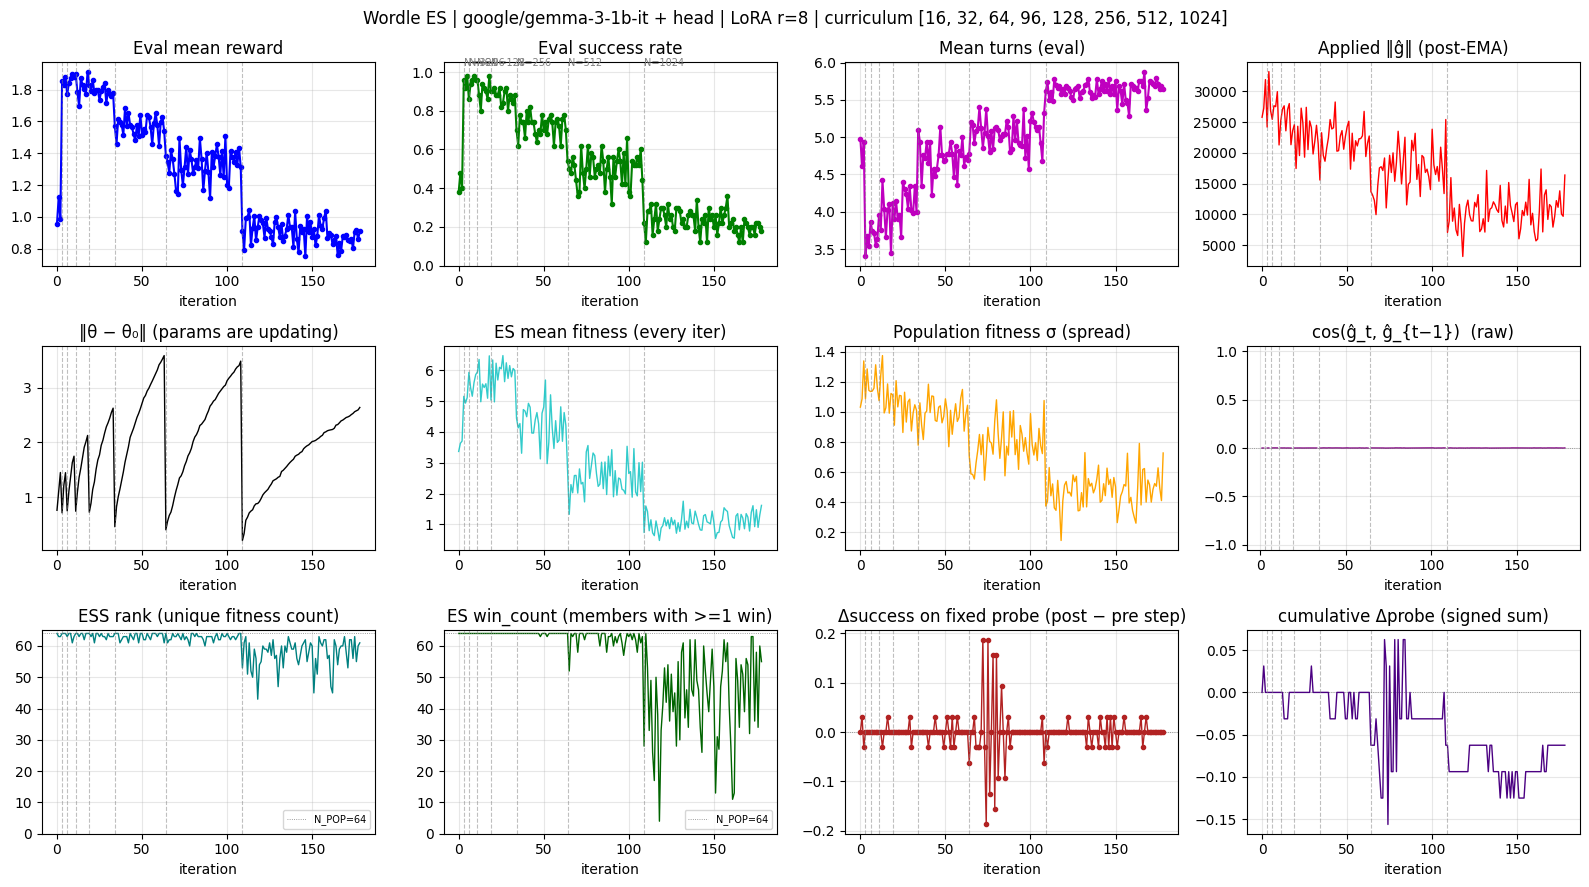

In [9]:
import matplotlib.pyplot as plt

it = history["iteration"]
ti = history["train_iter"]
fig, axes = plt.subplots(3, 4, figsize=(16, 9))

axes[0, 0].plot(it, history["eval_reward"], "b-o", ms=3)
axes[0, 0].set_title("Eval mean reward")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(it, history["eval_success"], "g-o", ms=3)
axes[0, 1].set_title("Eval success rate")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[0, 2].set_title("Mean turns (eval)")
axes[0, 2].set_xlabel("iteration")
axes[0, 2].grid(True, alpha=0.3)

axes[0, 3].plot(ti, history["train_grad_norm"], "r-", lw=1)
axes[0, 3].set_title("Applied ‖ĝ‖ (post-EMA)")
axes[0, 3].set_xlabel("iteration")
axes[0, 3].grid(True, alpha=0.3)

axes[1, 0].plot(ti, history["param_drift"], "k-", lw=1)
axes[1, 0].set_title("‖θ − θ₀‖ (params are updating)")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ti, history["train_fitness"], "c-", lw=1, alpha=0.8)
axes[1, 1].set_title("ES mean fitness (every iter)")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(ti, history["pop_fitness_std"], "orange", lw=1)
axes[1, 2].set_title("Population fitness σ (spread)")
axes[1, 2].set_xlabel("iteration")
axes[1, 2].grid(True, alpha=0.3)

# cos(ĝ_t, ĝ_{t-1}) on raw (pre-EMA) ES gradients. Healthy CRN run is
# clearly positive (signal beats noise) but well below 1 (secrets vary
# across iterations). Pinned near +1.0 at the start of a stage = a sign
# the CRN advance isn't decorrelating secrets across iterations.
gc_arr = np.array(history["train_grad_cos"], dtype=float)
axes[1, 3].plot(ti, gc_arr, "purple", lw=1)
axes[1, 3].axhline(0.0, color="gray", lw=0.6, ls=":")
axes[1, 3].set_title("cos(ĝ_t, ĝ_{t−1})  (raw)")
axes[1, 3].set_xlabel("iteration")
axes[1, 3].set_ylim(-1.05, 1.05)
axes[1, 3].grid(True, alpha=0.3)

# --- Bottom row: ES signal diagnostics ---
# train_ess_rank: number of unique fitness values across the population per
# iter. With rank_fitness=True and small n_eval_episodes, ties dominate when
# most members lose every episode; ess_rank << N_POP directly explains a
# near-zero cos(ĝ) above (the rank vector is near-uniform, so the ES gradient
# is a sum of noise vectors with near-uniform "fitness" weights).
ess_arr = np.array(history.get("train_ess_rank", []), dtype=float)
n_pop_const = int(N_POP) if "N_POP" in dir() else (
    max(int(v) for v in ess_arr) if len(ess_arr) > 0 else 1
)
axes[2, 0].plot(ti, ess_arr, color="teal", lw=1)
axes[2, 0].axhline(n_pop_const, color="gray", lw=0.6, ls=":", label=f"N_POP={n_pop_const}")
axes[2, 0].set_title("ESS rank (unique fitness count)")
axes[2, 0].set_xlabel("iteration")
axes[2, 0].set_ylim(0, max(2, n_pop_const + 1))
axes[2, 0].legend(loc="lower right", fontsize=7)
axes[2, 0].grid(True, alpha=0.3)

# train_win_count: number of population members with >=1 win this iter. 0 or 1
# means the rank ordering is essentially noise (all members tie at "lost
# everything", or one member wins and the rest tie at zero).
wc_arr = np.array(history.get("train_win_count", []), dtype=float)
axes[2, 1].plot(ti, wc_arr, color="darkgreen", lw=1)
axes[2, 1].axhline(n_pop_const, color="gray", lw=0.6, ls=":", label=f"N_POP={n_pop_const}")
axes[2, 1].set_title("ES win_count (members with >=1 win)")
axes[2, 1].set_xlabel("iteration")
axes[2, 1].set_ylim(0, max(2, n_pop_const + 1))
axes[2, 1].legend(loc="lower right", fontsize=7)
axes[2, 1].grid(True, alpha=0.3)

# train_probe_delta: change in greedy success on a fixed-seed eval probe before
# vs. after each ES step. NaN on non-eval iters (drawn as gaps). Persistent
# positives across iterations => ES is reliably *helping*; symmetric scatter
# around 0 => ES is moving the policy without improving it.
pd_arr = np.array(history.get("train_probe_delta", []), dtype=float)
pd_iter = np.array(ti, dtype=float)
pd_finite_mask = np.isfinite(pd_arr)
axes[2, 2].axhline(0.0, color="gray", lw=0.6, ls=":")
axes[2, 2].plot(
    pd_iter[pd_finite_mask], pd_arr[pd_finite_mask],
    "o-", ms=3, color="firebrick", lw=1,
)
axes[2, 2].set_title("Δsuccess on fixed probe (post − pre step)")
axes[2, 2].set_xlabel("iteration")
axes[2, 2].grid(True, alpha=0.3)

# Cumulative probe delta. If individual deltas are noisy but the cumulative
# trend is positive, ES is contributing on average even when single-iter
# deltas are dominated by probe-set variance.
pd_cum = np.cumsum(np.where(pd_finite_mask, pd_arr, 0.0))
axes[2, 3].axhline(0.0, color="gray", lw=0.6, ls=":")
axes[2, 3].plot(ti, pd_cum, color="indigo", lw=1)
axes[2, 3].set_title("cumulative Δprobe (signed sum)")
axes[2, 3].set_xlabel("iteration")
axes[2, 3].grid(True, alpha=0.3)

# Overlay curriculum stage boundaries on every subplot (skip the first stage's
# marker at iteration 0 to avoid clutter at the y-axis).
stage_starts = history.get("stage_starts", [])
stage_vocab_sizes = history.get("stage_vocab_sizes", [])
stage_secret_pool_sizes = history.get("stage_secret_pool_sizes", [])
# In the constant-action-dim setup, stage_vocab_sizes can be flat (e.g. all
# 1024) while the curriculum progresses by secret-pool size. Label boundaries
# by the varying schedule users actually care about.
stage_schedule_sizes = (
    stage_secret_pool_sizes
    if len(stage_secret_pool_sizes) == len(stage_starts)
    else stage_vocab_sizes
)
for ax in axes.flat:
    for s_idx, s_iter in enumerate(stage_starts):
        if s_iter <= 0:
            continue
        ax.axvline(s_iter, color="gray", lw=0.8, ls="--", alpha=0.5)
        if ax is axes[0, 1] and s_idx < len(stage_schedule_sizes):
            ax.text(
                s_iter, 1.02, f"N={stage_schedule_sizes[s_idx]}",
                fontsize=7, color="gray", ha="left", va="bottom",
            )

rank_note = f" | LoRA r={LORA_R}" if USE_LORA else ""
schedule_note = (
    f" | curriculum {stage_schedule_sizes}" if len(stage_schedule_sizes) > 1 else ""
)
plt.suptitle(f"Wordle ES | {MODEL_NAME} + head{rank_note}{schedule_note}")
plt.tight_layout()
plt.show()

## 7. Save checkpoint (optional)

Saves the **head** plus `words` and `history` under `models/` at the repo root when `USE_LORA=False`.

When `USE_LORA=True`, checkpoint saving is skipped to avoid writing large LoRA model files.

In [8]:
if USE_LORA:
    print(f"LoRA rank used for this run: r={LORA_R}")
    print("Skipping checkpoint save for LoRA run to avoid large model artifacts.")
else:
    save_path = ROOT / "models" / f"wordle_gemma_es_head.{RUN_PROFILE}.pt"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "head": policy.head.state_dict(),
        "model_name": MODEL_NAME,
        "words": policy.words,
        "history": history,
        "use_lora": USE_LORA,
        "run_profile": RUN_PROFILE,
        "model_load_kwargs": {k: str(v) for k, v in MODEL_LOAD_KWARGS.items()},
    }
    if getattr(policy, "_lm_trainable", False):
        payload["lm"] = policy.lm.state_dict()
    torch.save(payload, save_path)
    print("Saved:", save_path)

LoRA rank used for this run: r=8
Skipping checkpoint save for LoRA run to avoid large model artifacts.
